# HR Attrition Analytics — Exploratory Data Analysis

## Business Context
An HR team suspects high attrition is tied to specific departments,
overtime patterns, and salary bands. This analysis identifies the 
root causes to help management take targeted retention actions.

**Dataset:** IBM HR Analytics (Kaggle) — 1,470 employees, 35 features  
**Analyst:** Piumi Jayawardene  
**Date:** 2026

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
print("All libraries loaded successfully")

All libraries loaded successfully


In [26]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [27]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Attrition Distribution ===")
print(df["Attrition"].value_counts())
print("\n=== Attrition Rate ===")
attrition_rate = df["Attrition"].value_counts(normalize=True)["Yes"] * 100
print(f"{attrition_rate:.1f}% of employees left the company")

=== Missing Values ===
Series([], dtype: int64)

=== Attrition Distribution ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64

=== Attrition Rate ===
16.1% of employees left the company


In [28]:
df["Attrition_Flag"] = (df["Attrition"] == "Yes").astype(int)
print("Attrition_Flag created.")
print(df["Attrition_Flag"].value_counts())

Attrition_Flag created.
Attrition_Flag
0    1233
1     237
Name: count, dtype: int64


In [29]:
df.to_csv("../data/processed/hr_attrition_clean.csv", index=False)
print("Cleaned data saved to processed folder.")

Cleaned data saved to processed folder.


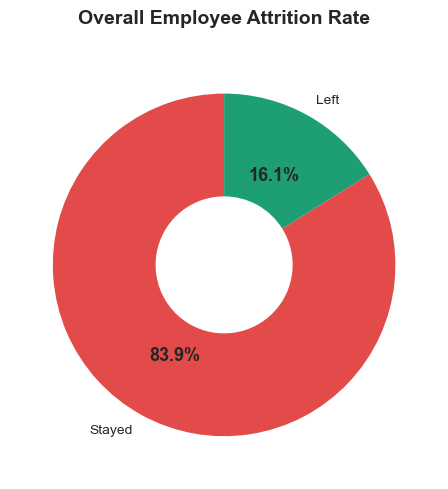

Attrition rate: 16.1%


In [30]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = df["Attrition"].value_counts()

colors = ["#E24B4A", "#1D9E75"]

wedges, texts, autotexts = ax.pie(
    counts,
    labels=["Stayed", "Left"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.6)
)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")

ax.set_title(
    "Overall Employee Attrition Rate",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart1_attrition_rate.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Attrition rate: {counts['Yes']/len(df)*100:.1f}%")

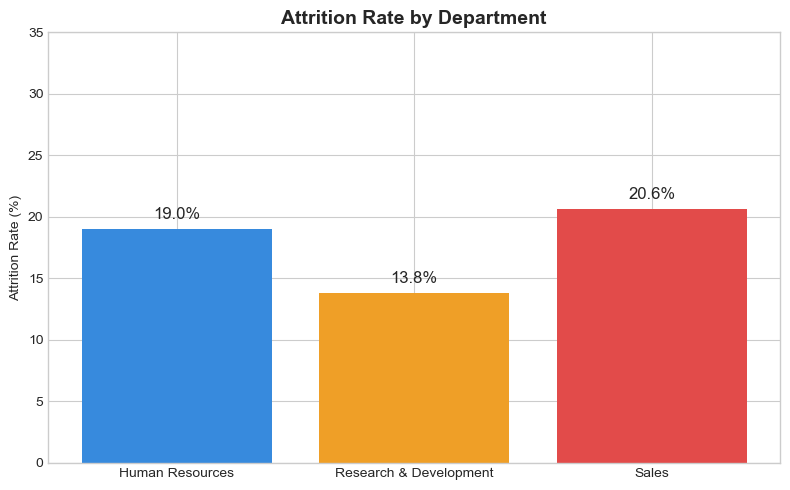

In [31]:
dept = df.groupby("Department")["Attrition_Flag"].agg(
    ["mean", "sum", "count"]
).reset_index()

dept.columns = [
    "Department",
    "Attrition_Rate",
    "Left",
    "Total"
]

dept["Attrition_Rate"] = dept["Attrition_Rate"] * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    dept["Department"],
    dept["Attrition_Rate"],
    color=["#378ADD", "#EF9F27", "#E24B4A"]
)

ax.bar_label(
    bars,
    fmt="%.1f%%",
    padding=5,
    fontsize=12
)

ax.set_title(
    "Attrition Rate by Department",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Attrition Rate (%)")

ax.set_ylim(0, 35)

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart2_dept_attrition.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

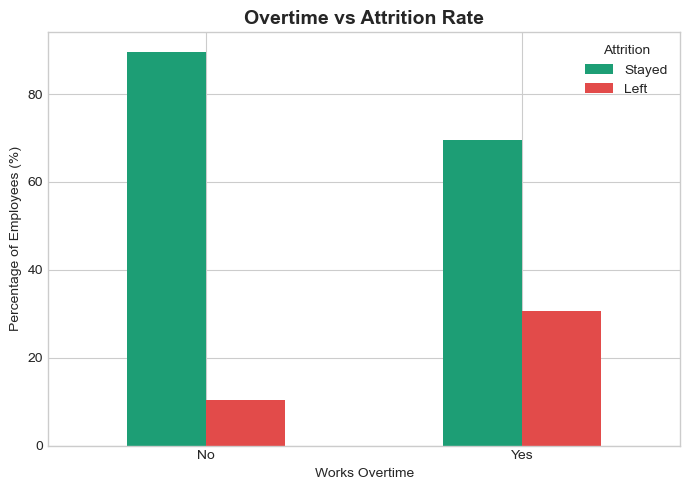

In [32]:
ot = df.groupby(["OverTime", "Attrition"]).size().unstack()

ot_pct = ot.div(ot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 5))

ot_pct.plot(
    kind="bar",
    ax=ax,
    color=["#1D9E75", "#E24B4A"],
    width=0.5,
    edgecolor="none"
)

ax.set_title(
    "Overtime vs Attrition Rate",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Percentage of Employees (%)")

ax.set_xlabel("Works Overtime")

ax.legend(
    ["Stayed", "Left"],
    title="Attrition"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart3_overtime_attrition.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

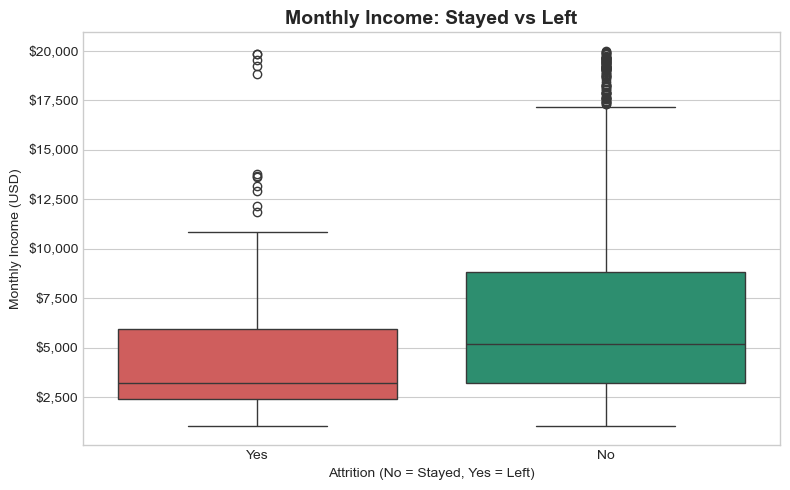

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="Attrition", y="MonthlyIncome",
    palette={"No":"#1D9E75","Yes":"#E24B4A"}, ax=ax
)
ax.set_title("Monthly Income: Stayed vs Left",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition (No = Stayed, Yes = Left)")
ax.set_ylabel("Monthly Income (USD)")
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f"${x:,.0f}")
)
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart4_income_attrition.png", dpi=150, bbox_inches="tight")
plt.show()

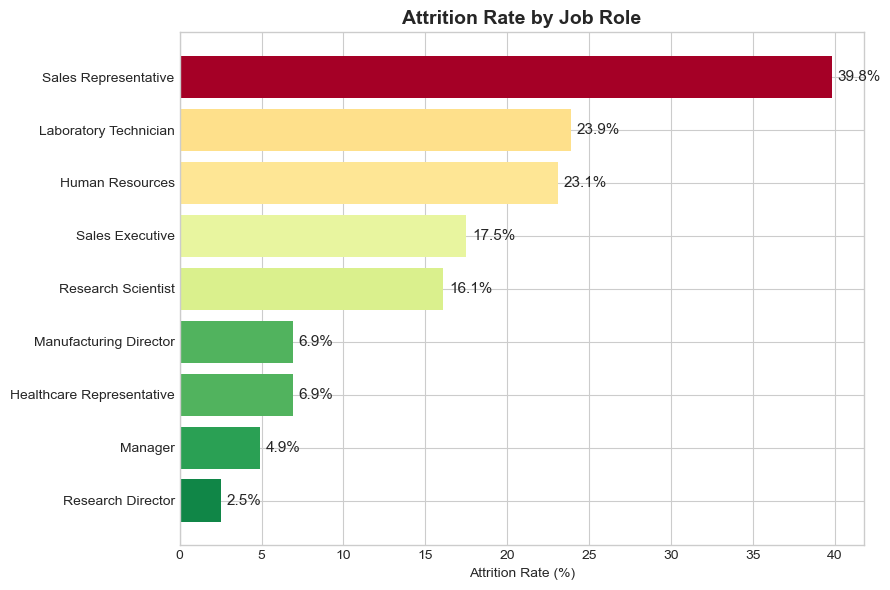

In [34]:
role_dept = df.groupby(["JobRole"])["Attrition_Flag"].agg(["mean","count"]).reset_index()
role_dept.columns = ["JobRole","Attrition_Rate","Count"]
role_dept["Attrition_Rate"] = (role_dept["Attrition_Rate"]*100).round(1)
role_dept = role_dept.sort_values("Attrition_Rate", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(role_dept["JobRole"], role_dept["Attrition_Rate"],
               color=plt.cm.RdYlGn_r(
                   role_dept["Attrition_Rate"]/role_dept["Attrition_Rate"].max()
               ))
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11)
ax.set_title("Attrition Rate by Job Role", fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart5_jobrole_attrition.png", dpi=150, bbox_inches="tight")
plt.show()



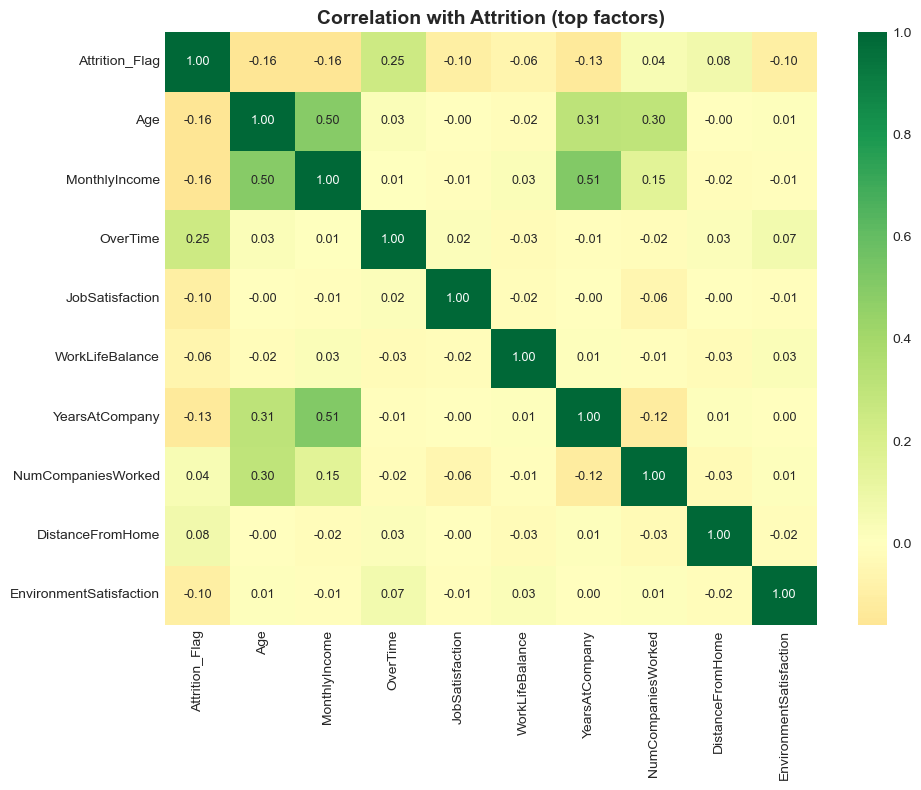

In [35]:
numeric_cols = [
    "Attrition_Flag","Age","MonthlyIncome","OverTime",
    "JobSatisfaction","WorkLifeBalance","YearsAtCompany",
    "NumCompaniesWorked","DistanceFromHome","EnvironmentSatisfaction"
]
df_heat = df[numeric_cols].copy()
df_heat["OverTime"] = (df_heat["OverTime"] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_heat.corr(), annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    annot_kws={"size":9}
)
ax.set_title("Correlation with Attrition (top factors)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart6_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings & Business Recommendations

### Findings
1. Overall attrition rate is **16.1%** — above the industry average of 10–12%
2. **Sales department** has the highest attrition compared to HR and R&D
3. Employees working **overtime are significantly more likely to leave**
4. Employees who left earned on average **lower monthly incomes**
5. Certain job roles show much higher attrition rates than others
6. Low job satisfaction and poor work-life balance correlate with attrition

### Recommendations
- Review overtime policies, especially in Sales
- Benchmark salaries for high-turnover job roles
- Conduct regular employee satisfaction surveys
- Improve work-life balance initiatives
- Implement early retention interventions for at-risk employees